In [2]:
# Step 1: Specify the path to the "experiment_analyses" folder in your system (after cloning the repo)
# This step is because I have a separate folder in the repo that contains the Jupyter Notebooks for organization purposes
import warnings
import os
experiment_analyses_dir = r"C:\Users\graci\OneDrive\Documents\Github\driving_exp_1_analyses\experiment_analyses"  # Replace with your desired directory
os.chdir(experiment_analyses_dir)


# Step 2: Specify the location of file paths contain the main_data folder
# I will share a Dropbox folder with you that contains these folders, so you can just copy and paste your file system file path to these
# Note that the files in these folders should be treated as immutable
import preprocess

SUBJECT_PATH = "C:/Users/graci/Dropbox/PAndA/Thesis Experiment 3/data/main_data" # Dropbox directory path that leads to the csv files for all subejcts across both familiar and unfamiliar group

# subject_dict: all keys are of each subject's id (e.g. "wad") and all values are of the subject_object (which will contain all the data for the subject)

warnings.filterwarnings("ignore")
subject_dict = preprocess.run(SUBJECT_PATH)

In [3]:
# Useful references -------------------------
control_group_ids = ["agony","both","cargo","cheek","cub", "desk","dingy","fetch","final","floss","fried","mount","pagan","slot", "snarl","spoof","tribe", "untie","width","wish"]
scrambled_segments_group_ids = ["brave","comic", "crop", "dial","donor","even","gave","gore","gray", "hump","jury","mud", "outer", "ozone", "relax","riot", "salon","unit", "upon", "zebra"]
scrambled_landmarks_group_ids = ["arena","chain","cloth","crept", "disk","elm","flask","flip","game","grab","grant","guy","jam","line","marry","ounce","river","roar","shred", "spoon"]

trial_list = [0,1,2,3,4,5,6,7,8,9,10] # I use 0th based lists to index the trials 

# Pick a trial number! -----------
trial_number = 9


In [8]:
import avg_heatmap

centerline_speed_dict_list_control,centerline_speed_dict_list_ss,centerline_speed_dict_list_sl = [],[],[]

# For every subject:
for subject_id in subject_dict:
    subject_object = subject_dict[subject_id] 
    trial_object = subject_object.trials[trial_number]

    track_centerline_x,track_centerline_y = trial_object.map.centerline_df['x'],trial_object.map.centerline_df['y']  # centerline
    speed_df = trial_object.paths["Vehicle_DrivingSim"][["velocity_magnitude","time"]] # DF for position over time
    position_df = trial_object.paths["main_camera"][["pos_x","pos_y","time"]] # DF for position over time

    # For every point along the center_line, get speed
    centerline_speed_dict = avg_heatmap.get_speeds_along_centerline(track_centerline_x, track_centerline_y, speed_df, position_df)

    if subject_object.condition == "control":
        centerline_speed_dict_list_control.append(centerline_speed_dict)
    elif subject_object.condition == "scrambled_segments":
        centerline_speed_dict_list_ss.append(centerline_speed_dict)
    elif subject_object.condition == "scrambled_landmarks":
        centerline_speed_dict_list_sl.append(centerline_speed_dict)

#  Master dictionary that specifies average speed for all subjects for each point along centerline
control_avg_speeds_dict = avg_heatmap.average_centerline_speeds(centerline_speed_dict_list_control)
ss_avg_speeds_dict = avg_heatmap.average_centerline_speeds(centerline_speed_dict_list_ss)
sl_avg_speeds_dict = avg_heatmap.average_centerline_speeds(centerline_speed_dict_list_sl)



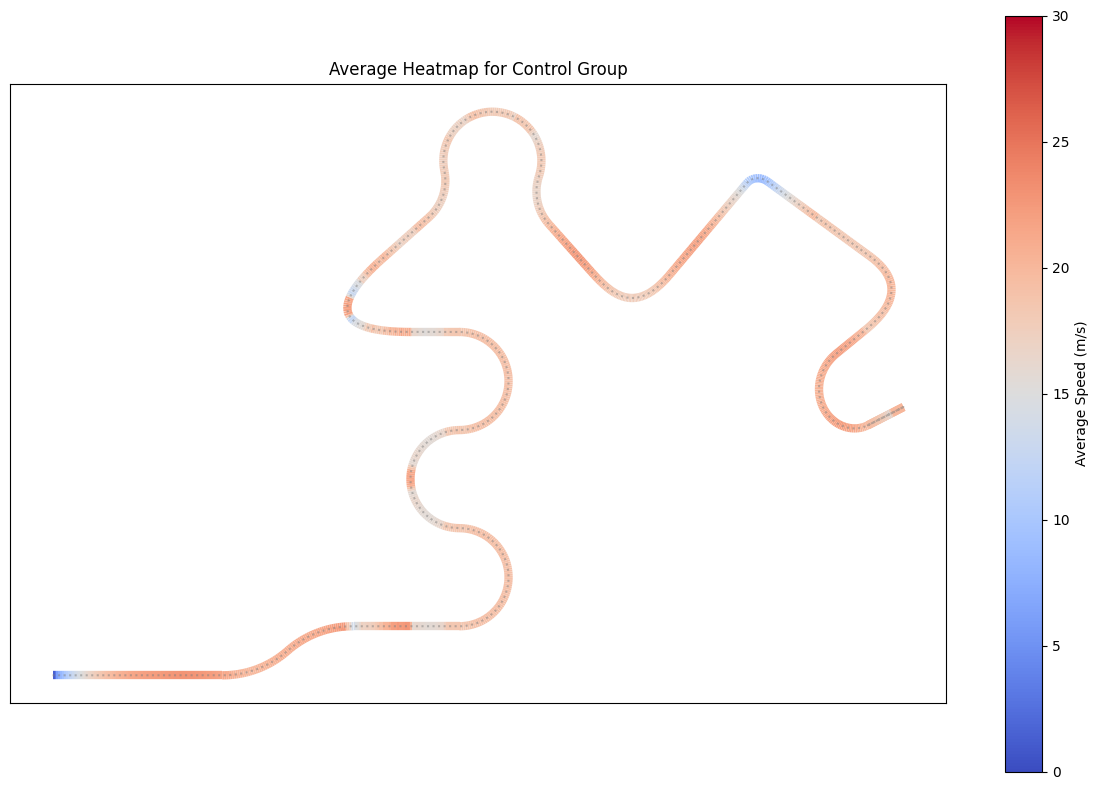

In [9]:
# Plot the heatmap! 
import matplotlib.pyplot as plt
avg_heatmap.plot_centerline_speed_heatmap("Control Group",track_centerline_x, track_centerline_y, control_avg_speeds_dict,trial_number)

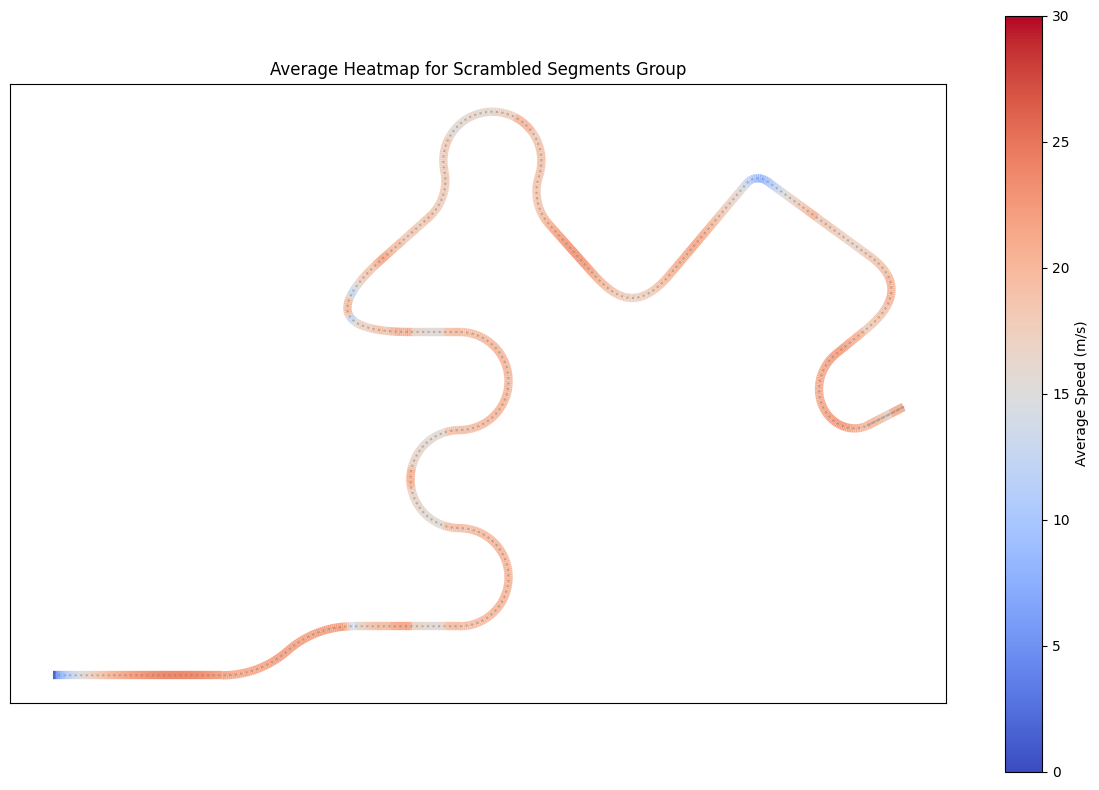

In [10]:
avg_heatmap.plot_centerline_speed_heatmap("Scrambled Segments Group",track_centerline_x, track_centerline_y, ss_avg_speeds_dict,trial_number)

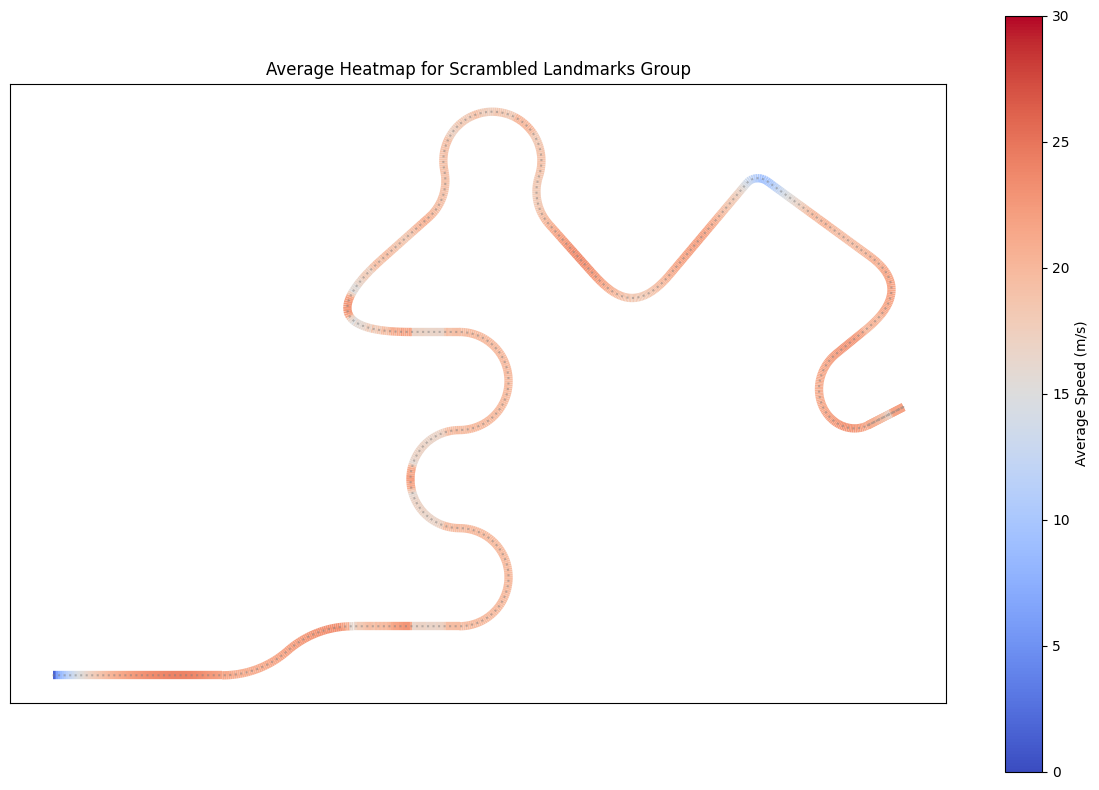

In [11]:
avg_heatmap.plot_centerline_speed_heatmap("Scrambled Landmarks Group",track_centerline_x, track_centerline_y, sl_avg_speeds_dict,trial_number)